# PDL Challenge 1: Neural Network-Based Function Upscaling

- **Task 1**: a DNN with 1 input and 1 output (at most 10,000 neurons) memorises one band-limited function. We study how it interpolates between the training points.
- **Task 2**: a DNN with 100 inputs and 512 outputs (at most 1,000,000 neurons) reconstructs a whole band-limited function from 100 samples, and must generalise to functions it has never seen.

Both tasks use the MSE loss and the Adam optimiser, trained until convergence as judged by early stopping. Following Section 5, each experiment changes one variable at a time, and every configuration is repeated with `N_SEEDS` different random initialisations so that we can compare means and standard deviations.

In [1]:
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

N = 512          # 函數的總點數 x = 1 ... 512 (程式中用 0-based 位置 0 ... 511)
BAND_LIMIT = 50  # 正頻率係數 1 ... 49 非零 加上共軛對稱的負頻率 共 98 個非零係數
N_SEEDS = 3      # 每個設定用幾組不同的隨機初始化重複訓練 (Section 5.2 第 4 點)
QUICK = False    # True: 只跑 1 個 seed 並縮短訓練 用來先確認整本 notebook 可以跑完

if QUICK:
    N_SEEDS = 1

TASK1_BUDGET = 10_000
TASK2_BUDGET = 1_000_000

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


## Shared utilities

`generate_bandlimited` follows the example code in the assignment and then multiplies the result by a fixed constant so that the function values have variance close to 1. The constant does not depend on the data, so the training and test sets share the same scale, and an MSE can be read directly as the error relative to the signal energy.

In [2]:
def set_seed(seed):
    # 固定 python / numpy / PyTorch 的隨機種子 讓結果可以重現
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def generate_bandlimited(num_functions, rng):
    coefficients = np.zeros((num_functions, N), dtype=np.complex128)
    coefficients[:, 1:BAND_LIMIT] = (rng.standard_normal((num_functions, BAND_LIMIT - 1))
                                     + 1j * rng.standard_normal((num_functions, BAND_LIMIT - 1)))  # 正頻率
    coefficients[:, -(BAND_LIMIT - 1):] = coefficients[:, 1:BAND_LIMIT][:, ::-1].conj()  # 負頻率 共軛對稱
    functions = np.fft.ifft(coefficients, axis=1).real
    # 每個點是 49 個獨立餘弦項的和 變異數為 4 * 49 / N^2 乘上這個係數後變異數約為 1
    return (functions * N / (2 * np.sqrt(BAND_LIMIT - 1))).astype(np.float32)


def sampling_positions(num_points, kind, rng=None):
    # 回傳已排序 不重複的 0-based 取樣位置
    if kind == 'regular':      # 等間隔
        return np.round(np.linspace(0, N - 1, num_points)).astype(int)
    if kind == 'irregular':    # 均勻隨機
        return np.sort(rng.choice(N, num_points, replace=False))
    if kind == 'exponential':  # 間隔呈指數成長 開頭密 結尾疏
        targets = np.round(np.geomspace(1, N, num_points)).astype(int) - 1
        positions = np.zeros(num_points, dtype=int)
        for i in range(1, num_points):
            positions[i] = max(targets[i], positions[i - 1] + 1)
        return positions
    raise ValueError(kind)


class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)


# 'sin' 是週期性的 activation 常用於表示訊號 'linear' 表示沒有非線性
ACTIVATIONS = {
    'linear': nn.Identity,
    'relu': nn.ReLU,
    'tanh': nn.Tanh,
    'sigmoid': nn.Sigmoid,
    'sin': Sine,
}


def build_mlp(input_dim, output_dim, hidden_layers, activation, neuron_budget):
    n_neurons = sum(hidden_layers) + output_dim
    assert n_neurons <= neuron_budget, f'{n_neurons} neurons exceeds the budget of {neuron_budget}'
    layers = []
    in_features = input_dim
    for units in hidden_layers:
        layers += [nn.Linear(in_features, units), ACTIVATIONS[activation]()]
        in_features = units
    layers.append(nn.Linear(in_features, output_dim))  # 輸出層不加 activation 輸出值不受限制
    return nn.Sequential(*layers).to(device)


def fit(model, x, y, max_epochs, patience, batch_size=None, x_val=None, y_val=None, min_delta=0.0, learning_rate=1e-3):
    # 用 Adam 和 MSE 訓練到收斂: 監看的 loss (有 validation 就看 validation loss 否則看訓練 loss)
    # 連續 patience 個 epoch 沒有進步就停止 並還原到最好的那組權重
    x = torch.as_tensor(x, dtype=torch.float32, device=device)
    y = torch.as_tensor(y, dtype=torch.float32, device=device)
    if x_val is not None:
        x_val = torch.as_tensor(x_val, dtype=torch.float32, device=device)
        y_val = torch.as_tensor(y_val, dtype=torch.float32, device=device)
    batch_size = batch_size or len(x)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()
    history = {'loss': [], 'val_loss': []}
    best_loss, best_state, epochs_without_improvement = float('inf'), None, 0

    for epoch in range(max_epochs):
        model.train()
        order = torch.randperm(len(x), device=device)
        epoch_loss = 0.0
        for start in range(0, len(x), batch_size):
            batch = order[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(x[batch]), y[batch])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        history['loss'].append(epoch_loss / len(x))

        if x_val is not None:
            model.eval()
            with torch.no_grad():
                history['val_loss'].append(loss_fn(model(x_val), y_val).item())
        monitored = history['val_loss'][-1] if x_val is not None else history['loss'][-1]

        if monitored < best_loss - min_delta:
            best_loss, epochs_without_improvement = monitored, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    return history


def predict(model, x):
    model.eval()
    with torch.no_grad():
        return model(torch.as_tensor(x, dtype=torch.float32, device=device)).cpu().numpy()


def arch_name(hidden_layers):
    return f'{len(hidden_layers)}x{hidden_layers[0]}'


def plot_heatmap(df, row, col, value, row_order, col_order, title):
    table = df.groupby([row, col])[value].mean().unstack(col).reindex(index=row_order, columns=col_order)
    fig, ax = plt.subplots(figsize=(1.5 * len(col_order) + 2, 0.7 * len(row_order) + 2))
    image = ax.imshow(np.log10(table.values), cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(col_order)), col_order)
    ax.set_yticks(range(len(row_order)), row_order)
    ax.set_xlabel(col)
    ax.set_ylabel(row)
    for i in range(len(row_order)):
        for j in range(len(col_order)):
            ax.text(j, i, f'{table.values[i, j]:.1e}', ha='center', va='center', color='white', fontsize=9)
    fig.colorbar(image, label=f'log10 {value} (mean over {N_SEEDS} seeds)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return table


def plot_vs_size(df, size_col, value, group_cols, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    for key, group in df.groupby(group_cols):
        key = key if isinstance(key, tuple) else (key,)
        stats = group.groupby(size_col)[value].agg(['mean', 'std']).fillna(0)
        ax.errorbar(stats.index, stats['mean'], yerr=stats['std'], marker='o', capsize=3, label=' / '.join(map(str, key)))
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel(size_col)
    ax.set_ylabel(f'{value} (mean ± std over {N_SEEDS} seeds)')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# Task 1: A DNN Learns to Reconstruct one Band-limited Function

- **Data**: M pairs (x, y) taken from one fixed band-limited function. The input x is rescaled to [-1, 1], because large raw inputs such as 1 ... 512 make training unstable.
- **Training**: full-batch training. The goal is to memorise the M points, so no regularisation is used, and early stopping monitors the training loss.
- **Evaluation**:
  - `train_mse`: error on the training points, i.e. how well the points were memorised.
  - `heldout_mse`: error on the positions that were not used for training, i.e. the quality of the interpolation between points. This is the quantity the assignment is most interested in.
  - `full_mse`: error over all 512 positions.

The target function has variance 0.60, so a network that outputs a flat line at the mean has an MSE of about 0.60. Dividing an MSE by 0.60 gives the fraction of the signal the network fails to reproduce.

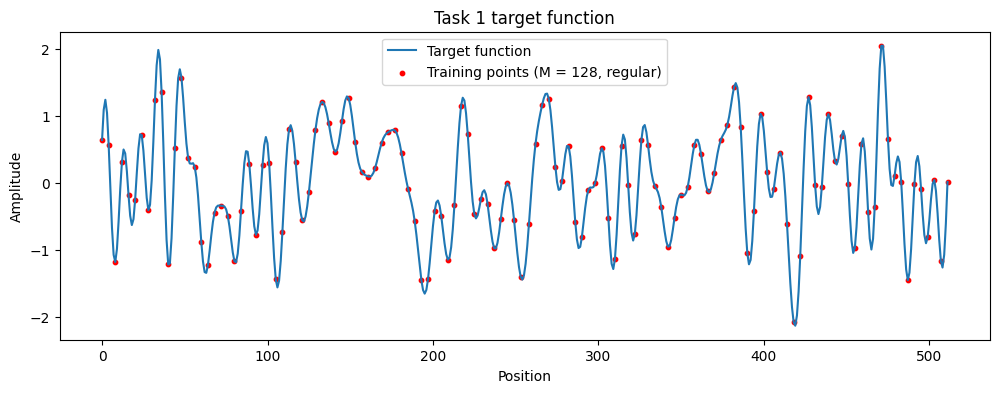

In [3]:
TASK1_MAX_EPOCHS = 1000 if QUICK else 5000
TASK1_PATIENCE = 300

f1 = generate_bandlimited(1, np.random.default_rng(42))[0]  # Task 1 的目標函數


def to_input(positions):
    # 位置 0 ... N-1 縮放到 [-1, 1]
    return (2 * np.asarray(positions) / (N - 1) - 1).reshape(-1, 1).astype(np.float32)


def train_task1(positions, hidden_layers, activation, seed):
    set_seed(seed)
    model = build_mlp(1, 1, hidden_layers, activation, TASK1_BUDGET)
    history = fit(model, to_input(positions), f1[positions].reshape(-1, 1), max_epochs=TASK1_MAX_EPOCHS,
                  patience=TASK1_PATIENCE, min_delta=1e-7)  # 整批 (full batch) 訓練
    prediction = predict(model, to_input(np.arange(N))).ravel()
    return prediction, history


def task1_metrics(prediction, positions):
    squared_error = (prediction - f1) ** 2
    held_out = np.setdiff1d(np.arange(N), positions)
    return {
        'train_mse': squared_error[positions].mean(),
        'heldout_mse': squared_error[held_out].mean() if len(held_out) else np.nan,
        'full_mse': squared_error.mean(),
    }


positions_128 = sampling_positions(128, 'regular')
plt.figure(figsize=(12, 4))
plt.plot(np.arange(N), f1, label='Target function')
plt.scatter(positions_128, f1[positions_128], s=10, color='red', label='Training points (M = 128, regular)')
plt.xlabel('Position')
plt.ylabel('Amplitude')
plt.title('Task 1 target function')
plt.legend()
plt.show()

## 1.1 Network architecture and activation function

The data is fixed (M = 128 regularly spaced points) while the architecture and the activation function change. Every architecture stays within the 10,000-neuron budget.

**Hypothesis**: a ReLU network is piecewise linear, so it joins the training points with straight segments, whereas smooth activations (tanh, sin) produce smoother interpolation. For the same number of neurons, a deeper network can represent more linear pieces but is harder to train.

In [4]:
TASK1_ARCHS = [[1024], [128] * 3, [128] * 6, [64] * 10]
TASK1_ACTIVATIONS = ['relu', 'tanh', 'sigmoid', 'sin']

task1_arch_records = []
task1_arch_predictions = {}  # 保留 seed 0 的預測 用來畫圖
for hidden_layers in TASK1_ARCHS:
    for activation in TASK1_ACTIVATIONS:
        for seed in range(N_SEEDS):
            start = time.time()
            prediction, history = train_task1(positions_128, hidden_layers, activation, seed)
            metrics = task1_metrics(prediction, positions_128)
            task1_arch_records.append({'architecture': arch_name(hidden_layers), 'activation': activation,
                                       'seed': seed, 'epochs': len(history['loss']), **metrics})
            if seed == 0:
                task1_arch_predictions[(arch_name(hidden_layers), activation)] = prediction
            print(f'{arch_name(hidden_layers):>6} {activation:>7} seed {seed}: '
                  f"train {metrics['train_mse']:.2e}, held-out {metrics['heldout_mse']:.2e}, "
                  f"{len(history['loss'])} epochs, {time.time() - start:.0f}s")

task1_arch_df = pd.DataFrame(task1_arch_records)

1x1024    relu seed 0: train 4.02e-01, held-out 4.13e-01, 5000 epochs, 9s
1x1024    relu seed 1: train 4.06e-01, held-out 4.18e-01, 5000 epochs, 6s
1x1024    relu seed 2: train 4.07e-01, held-out 4.17e-01, 5000 epochs, 6s
1x1024    tanh seed 0: train 5.28e-01, held-out 5.33e-01, 5000 epochs, 6s
1x1024    tanh seed 1: train 5.24e-01, held-out 5.29e-01, 5000 epochs, 5s
1x1024    tanh seed 2: train 5.26e-01, held-out 5.30e-01, 5000 epochs, 5s
1x1024 sigmoid seed 0: train 5.85e-01, held-out 5.89e-01, 5000 epochs, 5s
1x1024 sigmoid seed 1: train 5.85e-01, held-out 5.89e-01, 5000 epochs, 5s
1x1024 sigmoid seed 2: train 5.85e-01, held-out 5.89e-01, 5000 epochs, 5s
1x1024     sin seed 0: train 5.80e-01, held-out 5.82e-01, 5000 epochs, 7s
1x1024     sin seed 1: train 5.80e-01, held-out 5.82e-01, 5000 epochs, 7s
1x1024     sin seed 2: train 5.80e-01, held-out 5.82e-01, 5000 epochs, 7s
 3x128    relu seed 0: train 2.72e-01, held-out 2.85e-01, 5000 epochs, 11s
 3x128    relu seed 1: train 2.63e-01

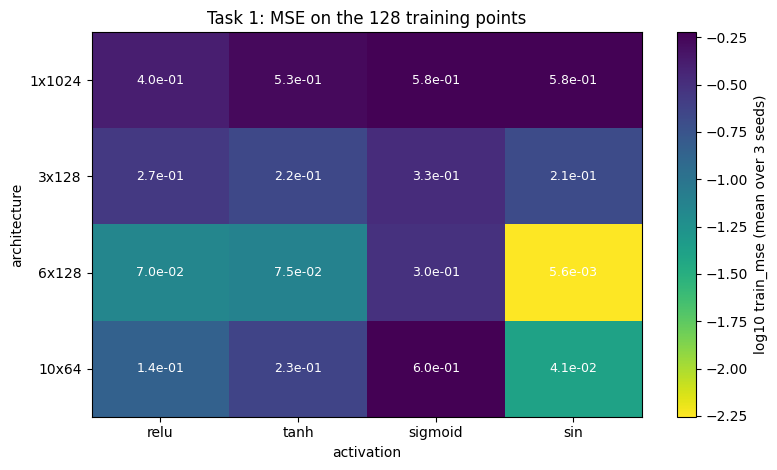

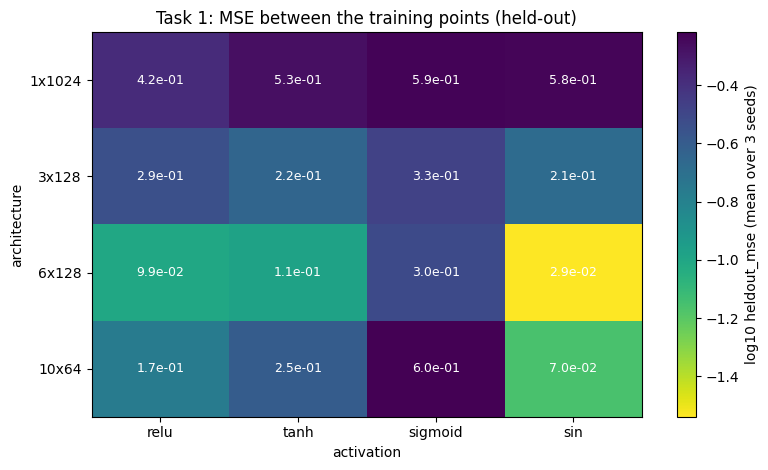

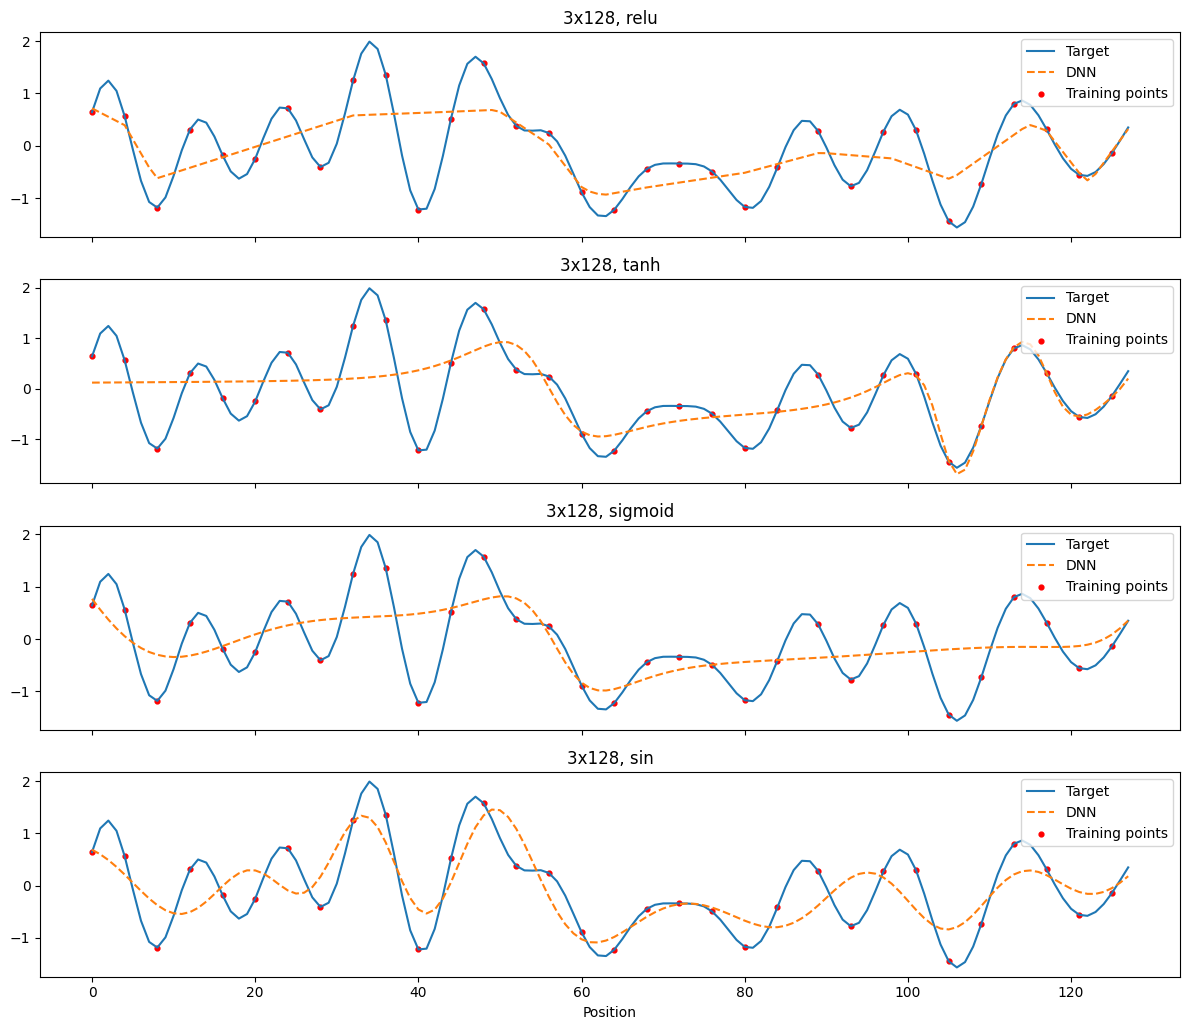

In [5]:
arch_order = [arch_name(h) for h in TASK1_ARCHS]
plot_heatmap(task1_arch_df, 'architecture', 'activation', 'train_mse', arch_order, TASK1_ACTIVATIONS,
             'Task 1: MSE on the 128 training points')
plot_heatmap(task1_arch_df, 'architecture', 'activation', 'heldout_mse', arch_order, TASK1_ACTIVATIONS,
             'Task 1: MSE between the training points (held-out)')

# 各 activation 在 3x128 網路上的重建結果 (seed 0) 放大前 128 個位置 才看得出點與點之間的形狀
fig, axes = plt.subplots(len(TASK1_ACTIVATIONS), 1, figsize=(12, 2.6 * len(TASK1_ACTIVATIONS)), sharex=True)
zoom = np.arange(128)
for ax, activation in zip(axes, TASK1_ACTIVATIONS):
    ax.plot(zoom, f1[zoom], label='Target')
    ax.plot(zoom, task1_arch_predictions[('3x128', activation)][zoom], '--', label='DNN')
    in_zoom = positions_128[positions_128 < len(zoom)]
    ax.scatter(in_zoom, f1[in_zoom], s=12, color='red', label='Training points')
    ax.set_title(f'3x128, {activation}')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Position')
plt.tight_layout()
plt.show()

**Observations**

- **Depth matters more than width.** With the same budget, the single wide layer (1x1024) is the worst architecture for ReLU, tanh and sin, and nearly the worst for sigmoid: its held-out MSE is 0.42 to 0.59, i.e. 69% to 98% of the signal variance, so it learns little more than the mean. The 6x128 network is the best architecture for every activation.
- **The best configuration is 6x128 with sin**, with a mean train MSE of 0.0056 and a mean held-out MSE of 0.029 (about 5% of the signal variance). The reconstruction follows the target closely. The 10x64 network with sin is second (held-out MSE 0.070).
- **Sigmoid is the worst activation.** 10x64 with sigmoid stops after about 400 epochs at an MSE of 0.60, which is exactly the variance of the target: the deep sigmoid network does not train at all, consistent with vanishing gradients.
- **The ReLU hypothesis is only partly supported.** The zoomed 3x128 plots show that ReLU, tanh and sigmoid capture the slow variations of the function but miss most of the fast oscillations, and the fitted curves do not pass through all the training points. The limiting factor at this size is not the shape of the interpolation between points but the network's inability to fit high frequencies at all (spectral bias). sin reproduces noticeably more of the oscillations.
- **Held-out error tracks training error.** For most configurations the held-out MSE is only slightly above the train MSE, so the error comes from underfitting rather than from poor interpolation. A clear gap between the two only appears for the configurations that fit the training points best, such as 6x128 with ReLU, tanh or sin.
- **Many runs reach the 5,000-epoch limit**, so they are not fully converged. The ranking of configurations is consistent across the three seeds, but the absolute errors of the slower configurations would likely decrease with longer training.

## 1.2 Dataset size and regular vs irregular evaluation points

The network is fixed (3x128) while the number of training points M and the sampling pattern change: regularly spaced or uniformly random (irregular). The irregular positions change with the seed, so the standard deviation also reflects the randomness of the positions.

**Hypothesis**: the highest frequency of the function is 49 cycles over the domain, so by the Nyquist sampling theorem roughly 2 × 49 = 98 regularly spaced samples are needed to determine the function. Below this value the held-out error should be large, and above it the error should drop quickly. Irregular sampling leaves larger gaps, so for the same M its error should be larger.

In [6]:
TASK1_SIZES = [16, 32, 64, 128, 256]
TASK1_SIZE_ACTIVATIONS = ['relu', 'sin']
TASK1_SIZE_ARCH = [128] * 3

task1_size_records = []
task1_size_predictions = {}
for num_points in TASK1_SIZES:
    for kind in ['regular', 'irregular']:
        for activation in TASK1_SIZE_ACTIVATIONS:
            for seed in range(N_SEEDS):
                positions = sampling_positions(num_points, kind, np.random.default_rng(1000 + seed))
                start = time.time()
                prediction, history = train_task1(positions, TASK1_SIZE_ARCH, activation, seed)
                metrics = task1_metrics(prediction, positions)
                task1_size_records.append({'M': num_points, 'sampling': kind, 'activation': activation,
                                           'seed': seed, **metrics})
                if seed == 0:
                    task1_size_predictions[(num_points, kind, activation)] = (positions, prediction)
                print(f'M {num_points:>3} {kind:>9} {activation:>4} seed {seed}: '
                      f"held-out {metrics['heldout_mse']:.2e}, {time.time() - start:.0f}s")

task1_size_df = pd.DataFrame(task1_size_records)

M  16   regular relu seed 0: held-out 7.89e-01, 2s
M  16   regular relu seed 1: held-out 7.88e-01, 3s
M  16   regular relu seed 2: held-out 7.66e-01, 4s
M  16   regular  sin seed 0: held-out 9.07e-01, 1s
M  16   regular  sin seed 1: held-out 9.56e-01, 1s
M  16   regular  sin seed 2: held-out 9.70e-01, 2s
M  16 irregular relu seed 0: held-out 3.66e+00, 7s
M  16 irregular relu seed 1: held-out 2.24e+00, 7s
M  16 irregular relu seed 2: held-out 1.82e+00, 7s
M  16 irregular  sin seed 0: held-out 2.76e+00, 7s
M  16 irregular  sin seed 1: held-out 2.46e+00, 8s
M  16 irregular  sin seed 2: held-out 8.20e+00, 9s
M  32   regular relu seed 0: held-out 6.60e-01, 10s
M  32   regular relu seed 1: held-out 6.88e-01, 10s
M  32   regular relu seed 2: held-out 6.66e-01, 10s
M  32   regular  sin seed 0: held-out 7.09e-01, 6s
M  32   regular  sin seed 1: held-out 6.80e-01, 7s
M  32   regular  sin seed 2: held-out 7.38e-01, 7s
M  32 irregular relu seed 0: held-out 6.45e-01, 9s
M  32 irregular relu seed 1:

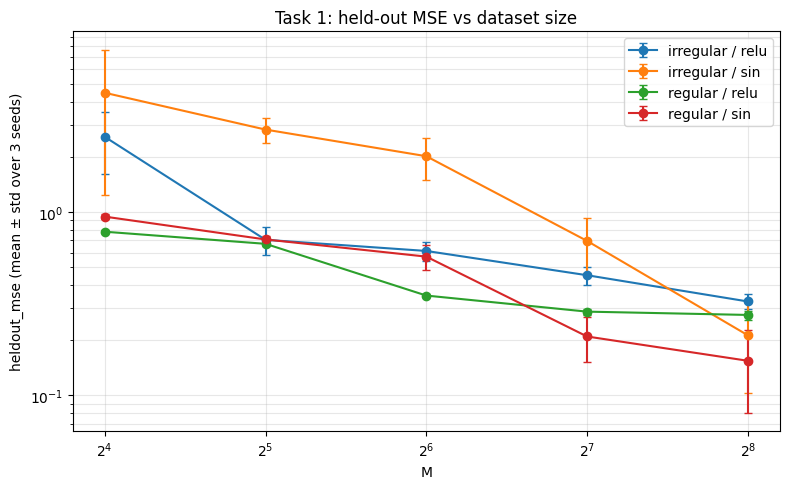

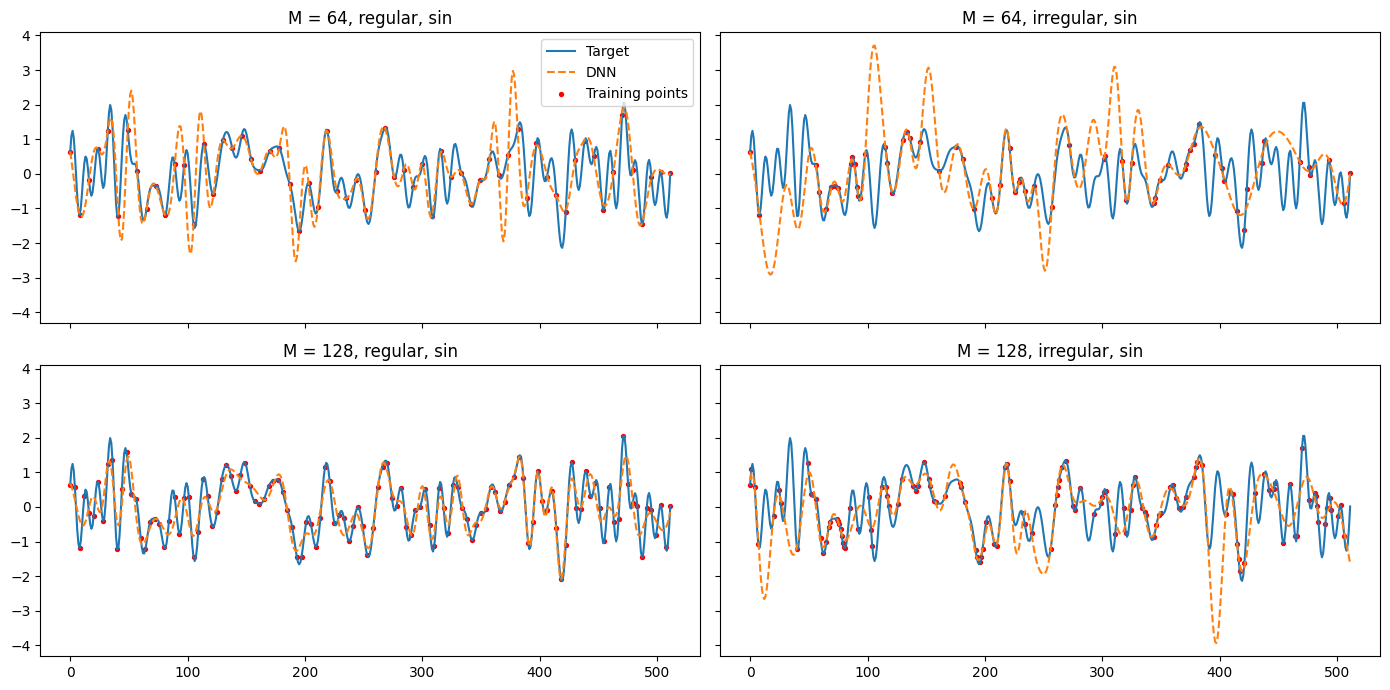

In [7]:
plot_vs_size(task1_size_df, 'M', 'heldout_mse', ['sampling', 'activation'],
             'Task 1: held-out MSE vs dataset size')

# M = 64 和 M = 128 時 regular 與 irregular 的重建結果 (sin, seed 0)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
for row, num_points in enumerate([64, 128]):
    for col, kind in enumerate(['regular', 'irregular']):
        positions, prediction = task1_size_predictions[(num_points, kind, 'sin')]
        ax = axes[row, col]
        ax.plot(f1, label='Target')
        ax.plot(prediction, '--', label='DNN')
        ax.scatter(positions, f1[positions], s=8, color='red', label='Training points')
        ax.set_title(f'M = {num_points}, {kind}, sin')
axes[0, 0].legend(loc='upper right')
plt.tight_layout()
plt.show()

**Observations**

- **More points reduce the error.** With regular sampling and sin, the held-out MSE falls from 0.94 at M = 16 to 0.57 at M = 64, 0.21 at M = 128 and 0.15 at M = 256. The largest single drop is between M = 64 and M = 128, which brackets the Nyquist value of about 98, so the result is consistent with the hypothesis. ReLU improves more gradually (0.35 at M = 64, 0.29 at M = 128, 0.28 at M = 256) and levels off, because the 3x128 ReLU network cannot fit the fast oscillations even when enough points are given (see 1.1).
- **The threshold is not sharp.** Above M = 98 the error keeps decreasing slowly instead of dropping to near zero, because at this network size the error is dominated by underfitting rather than by missing information. The Nyquist hypothesis is therefore supported in direction but cannot be confirmed as a sharp transition with this architecture.
- **Irregular sampling is worse, as expected.** At M = 64 the held-out MSE is 0.61 (ReLU) and 2.0 (sin) compared with 0.35 and 0.57 for regular sampling. The gap closes as M grows: at M = 256 irregular sin reaches 0.21 against 0.15 for regular.
- **sin overshoots in large gaps.** With irregular sampling and few points, the sin network invents large oscillations inside the gaps (amplitudes of 3 to 4, while the target stays within about ±2), giving held-out MSEs above 2 for M up to 64. ReLU also fails at M = 16 (2.6) but stays below 1 from M = 32 onwards. A periodic activation interpolates better when the points are dense and regular, but extrapolates less safely across large gaps.

---
# Task 2: Reconstruction of Band-limited Functions

- **Data**: each example is a new random band-limited function f_m. The input is f_m evaluated on 100 fixed positions X (size 100), and the label is f_m evaluated on all 512 positions (size 512).
- **Evaluation**: 1,000 test functions that are never used in training, to measure how well the network generalises to the class of band-limited functions:
  - `test_mse`: error over all 512 positions.
  - `between_mse`: error at positions outside X, i.e. the interpolation between samples.
  - `on_samples_mse`: error at the positions in X, where copying the input would already be exact.
- **Training**: 10% of the training functions are held out for validation, and early stopping monitors the validation loss.
- **Reference**: when the band limit is known, reconstruction is a linear least-squares problem with 98 unknown coefficients and 100 samples. `classical_reconstruction` solves it directly and represents what a classical linear method achieves with the same samples. With regular sampling it reconstructs perfectly. The less uniform the sampling, the more ill-conditioned the problem becomes, so errors are amplified, and with exponential sampling it fails completely. This lets us check whether a DNN is more robust than the classical method under irregular sampling.

Classical least-squares reconstruction,     regular X: test MSE 1.04e-15
Classical least-squares reconstruction,   irregular X: test MSE 4.83e-04
Classical least-squares reconstruction, exponential X: test MSE 2.19e+07


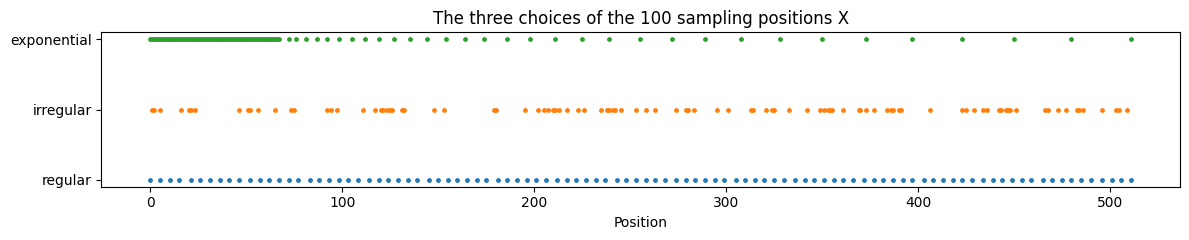

In [8]:
TASK2_MAX_EPOCHS = 100 if QUICK else 500
TASK2_PATIENCE = 30
NUM_SAMPLES = 100

task2_train_pool = generate_bandlimited(4000, np.random.default_rng(0))   # 訓練函數 前 M 條拿來訓練
task2_test = generate_bandlimited(1000, np.random.default_rng(2024))      # 測試函數 從未參與訓練

X_SETS = {
    'regular': sampling_positions(NUM_SAMPLES, 'regular'),
    'irregular': sampling_positions(NUM_SAMPLES, 'irregular', np.random.default_rng(7)),
    'exponential': sampling_positions(NUM_SAMPLES, 'exponential'),
}


def train_task2(num_functions, positions, hidden_layers, activation, seed):
    set_seed(seed)
    model = build_mlp(len(positions), N, hidden_layers, activation, TASK2_BUDGET)
    functions = task2_train_pool[:num_functions]
    n_val = num_functions // 10  # 最後 10% 的訓練函數做 validation
    train, val = functions[:-n_val], functions[-n_val:]
    history = fit(model, train[:, positions], train, max_epochs=TASK2_MAX_EPOCHS, patience=TASK2_PATIENCE,
                  batch_size=64, x_val=val[:, positions], y_val=val)
    return model, history


def task2_metrics(prediction, positions):
    squared_error = (prediction - task2_test) ** 2
    between = np.setdiff1d(np.arange(N), positions)
    return {
        'test_mse': squared_error.mean(),
        'between_mse': squared_error[:, between].mean(),
        'on_samples_mse': squared_error[:, positions].mean(),
    }


def classical_reconstruction(samples, positions):
    # 以頻率 1 ... 49 的 cos / sin 為基底 用最小平方從取樣值解出係數 再算出全部 512 個點
    n = np.arange(N)[:, None]
    k = np.arange(1, BAND_LIMIT)[None, :]
    basis = np.hstack([np.cos(2 * np.pi * k * n / N), np.sin(2 * np.pi * k * n / N)])
    coefficients, *_ = np.linalg.lstsq(basis[positions], samples.T, rcond=None)
    return (basis @ coefficients).T


for kind, positions in X_SETS.items():
    metrics = task2_metrics(classical_reconstruction(task2_test[:, positions], positions), positions)
    print(f'Classical least-squares reconstruction, {kind:>11} X: test MSE {metrics["test_mse"]:.2e}')

plt.figure(figsize=(12, 2.5))
for i, (kind, positions) in enumerate(X_SETS.items()):
    plt.scatter(positions, np.full(len(positions), i), s=6, label=kind)
plt.yticks(range(len(X_SETS)), list(X_SETS))
plt.xlabel('Position')
plt.title('The three choices of the 100 sampling positions X')
plt.tight_layout()
plt.show()

## 2.1 Baseline

Regular X, M = 2,000 training functions, and a 3x512 ReLU network.

The baseline reaches a test MSE of 0.049, about 5% of the signal variance, on functions it has never seen. The reconstructions of the three test functions follow the targets closely, with small errors mainly at the peaks. The network has learned a general reconstruction operator rather than memorising the training functions.

{'test_mse': np.float32(0.04906136), 'between_mse': np.float32(0.049128853), 'on_samples_mse': np.float32(0.04878328)}


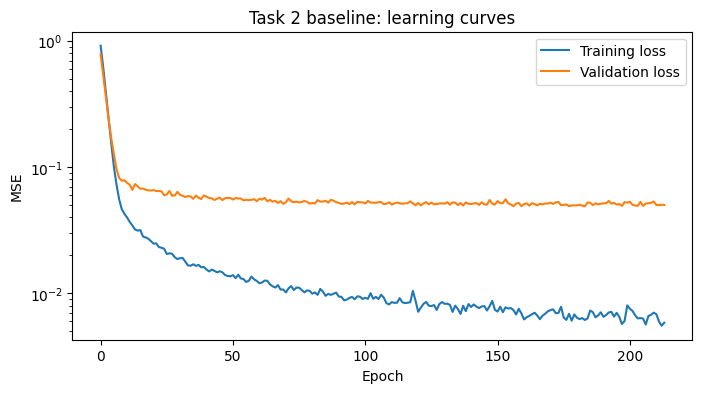

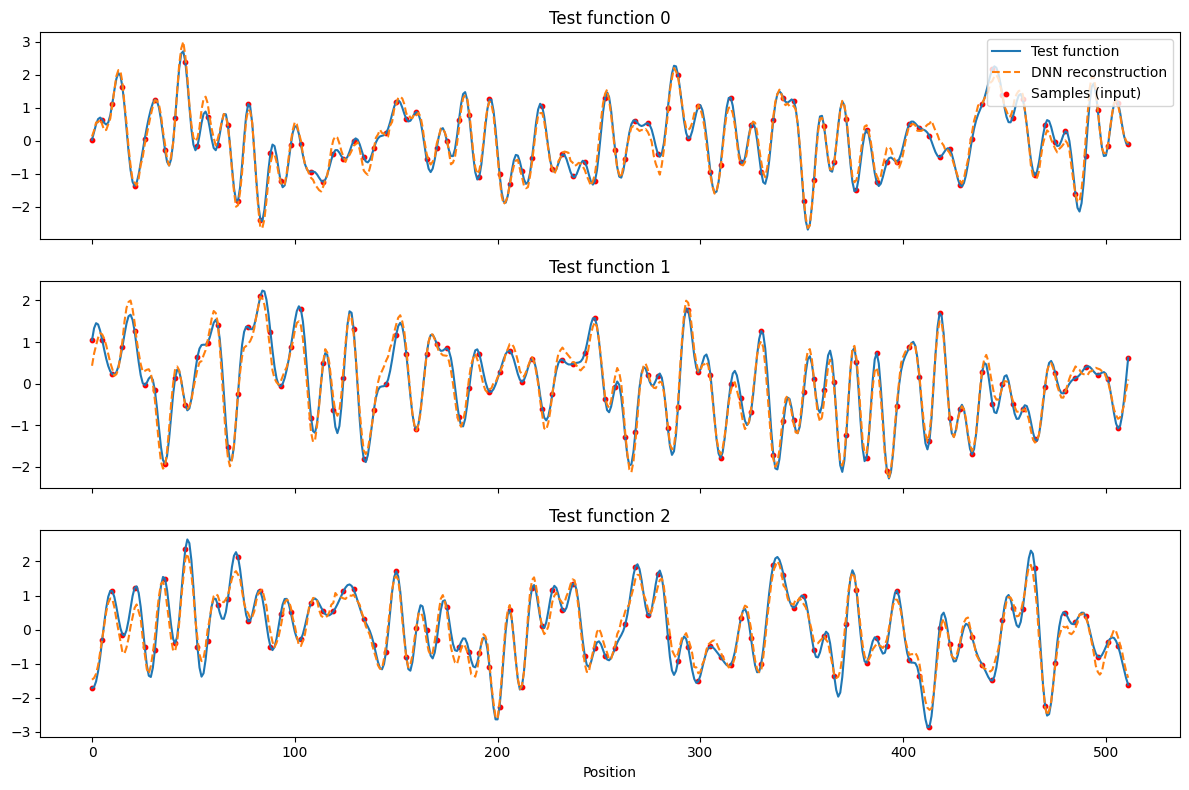

In [9]:
TASK2_BASE_ARCH = [512] * 3
TASK2_BASE_M = 2000

base_model, base_history = train_task2(TASK2_BASE_M, X_SETS['regular'], TASK2_BASE_ARCH, 'relu', seed=0)
base_prediction = predict(base_model, task2_test[:, X_SETS['regular']])
print(task2_metrics(base_prediction, X_SETS['regular']))

plt.figure(figsize=(8, 4))
plt.plot(base_history['loss'], label='Training loss')
plt.plot(base_history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Task 2 baseline: learning curves')
plt.legend()
plt.show()

# 三條測試函數的重建結果
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, i in zip(axes, range(3)):
    ax.plot(task2_test[i], label='Test function')
    ax.plot(base_prediction[i], '--', label='DNN reconstruction')
    ax.scatter(X_SETS['regular'], task2_test[i, X_SETS['regular']], s=10, color='red', label='Samples (input)')
    ax.set_title(f'Test function {i}')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('Position')
plt.tight_layout()
plt.show()

## 2.2 Network architecture and activation function

X is regular and M = 2,000, while the architecture and the activation function change. 'linear' means the network has no nonlinearity at all, so it can only represent linear maps.

**Hypothesis**: when the band limit is known, recovering a function from its samples is itself a linear map, so a linear network should in principle learn a near-perfect reconstruction. Nonlinear activations have to approximate a linear map and should therefore need more data to reach the same accuracy.

In [10]:
TASK2_ARCHS = [[256] * 2, [512] * 3, [1024] * 4]
TASK2_ACTIVATIONS = ['linear', 'relu', 'tanh', 'sigmoid', 'sin']

task2_arch_records = []
for hidden_layers in TASK2_ARCHS:
    for activation in TASK2_ACTIVATIONS:
        for seed in range(N_SEEDS):
            start = time.time()
            model, history = train_task2(TASK2_BASE_M, X_SETS['regular'], hidden_layers, activation, seed)
            prediction = predict(model, task2_test[:, X_SETS['regular']])
            metrics = task2_metrics(prediction, X_SETS['regular'])
            task2_arch_records.append({'architecture': arch_name(hidden_layers), 'activation': activation,
                                       'seed': seed, 'epochs': len(history['loss']), **metrics})
            print(f'{arch_name(hidden_layers):>6} {activation:>7} seed {seed}: '
                  f"test {metrics['test_mse']:.2e}, {len(history['loss'])} epochs, {time.time() - start:.0f}s")

task2_arch_df = pd.DataFrame(task2_arch_records)

 2x256  linear seed 0: test 1.38e-13, 48 epochs, 3s
 2x256  linear seed 1: test 1.38e-13, 49 epochs, 3s
 2x256  linear seed 2: test 1.37e-13, 49 epochs, 3s
 2x256    relu seed 0: test 7.95e-03, 190 epochs, 11s
 2x256    relu seed 1: test 8.06e-03, 157 epochs, 9s
 2x256    relu seed 2: test 8.20e-03, 155 epochs, 9s
 2x256    tanh seed 0: test 5.47e-03, 371 epochs, 21s
 2x256    tanh seed 1: test 5.29e-03, 381 epochs, 21s
 2x256    tanh seed 2: test 5.42e-03, 376 epochs, 22s
 2x256 sigmoid seed 0: test 7.48e-03, 500 epochs, 29s
 2x256 sigmoid seed 1: test 7.37e-03, 500 epochs, 28s
 2x256 sigmoid seed 2: test 7.36e-03, 500 epochs, 30s
 2x256     sin seed 0: test 3.93e-03, 259 epochs, 15s
 2x256     sin seed 1: test 3.65e-03, 295 epochs, 18s
 2x256     sin seed 2: test 3.60e-03, 402 epochs, 24s
 3x512  linear seed 0: test 3.39e-05, 39 epochs, 4s
 3x512  linear seed 1: test 4.03e-05, 38 epochs, 4s
 3x512  linear seed 2: test 4.18e-05, 38 epochs, 4s
 3x512    relu seed 0: test 4.91e-02, 214 

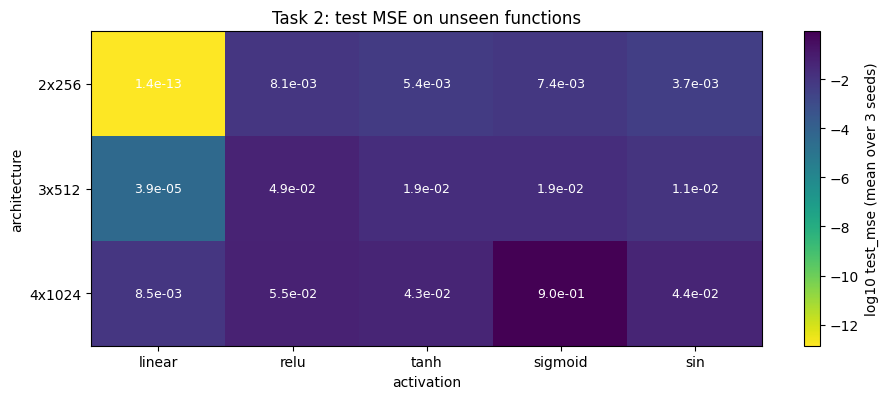

test_mse   between_mse  on_samples_mse
architecture activation                                            
2x256        linear      1.376851e-13  1.378942e-13    1.368237e-13
             relu        8.067499e-03  8.064678e-03    8.079120e-03
             sigmoid     7.400803e-03  7.400280e-03    7.402954e-03
             sin         3.727128e-03  3.727092e-03    3.727279e-03
             tanh        5.391878e-03  5.392055e-03    5.391148e-03
3x512        linear      3.866006e-05  3.892182e-05    3.758161e-05
             relu        4.872800e-02  4.880245e-02    4.842128e-02
             sigmoid     1.925815e-02  1.926246e-02    1.924039e-02
             sin         1.064353e-02  1.064133e-02    1.065259e-02
             tanh        1.937134e-02  1.937180e-02    1.936942e-02
4x1024       linear      8.501507e-03  8.512980e-03    8.454238e-03
             relu        5.508821e-02  5.519457e-02    5.465000e-02
             sigmoid     9.013179e-01  9.016374e-01    9.000013e-01
             sin         4.386995e-02  4.390549e-02    4.372353e-02
             tanh        4.320808e-02  4.322668e-02    4.313146e-02

In [11]:
plot_heatmap(task2_arch_df, 'architecture', 'activation', 'test_mse', [arch_name(h) for h in TASK2_ARCHS],
             TASK2_ACTIVATIONS, 'Task 2: test MSE on unseen functions')
task2_arch_df.groupby(['architecture', 'activation'])[['test_mse', 'between_mse', 'on_samples_mse']].mean()

**Observations**

- **The linear network is the best, confirming the hypothesis.** The 2x256 linear network reaches a test MSE of 1.4e-13, i.e. perfect reconstruction, matching the classical least-squares method, and it converges in under 50 epochs. The best nonlinear network is about ten orders of magnitude worse.
- **Among nonlinear activations, sin is the best and ReLU the worst.** On 2x256 the test MSE is 3.7e-3 (sin), 5.4e-3 (tanh), 7.4e-3 (sigmoid) and 8.1e-3 (ReLU). All of them still reconstruct the functions well in absolute terms (below 1% of the signal variance).
- **Larger networks are worse.** For every activation, 2x256 beats 3x512, which beats 4x1024. 4x1024 with sigmoid fails completely (test MSE 0.90, close to outputting zero), and the 4x1024 linear network varies strongly between seeds (2.3e-3 to 2.0e-2), which suggests that deep networks are harder to optimise here. With only 1,800 training functions, the additional capacity is not needed and makes optimisation harder. We did not test whether more data or a longer patience would change this ordering.
- **Errors are spread evenly.** For every configuration `between_mse` and `on_samples_mse` are almost equal, so the nonlinear networks do not even reproduce their own input samples exactly. They learn an approximate global map instead of copying the samples and filling the gaps.

## 2.3 Dataset size and the choice of X

The network is fixed (3x512, ReLU) while the number of training functions M and the sampling positions X (regular, irregular, exponential) change. To also compare activations, add `'linear'` to `TASK2_SIZE_ACTIVATIONS`, which doubles the training time.

**Hypothesis**: the test MSE decreases as M grows. Exponential sampling leaves large gaps towards the end of the domain, so the error there should be much larger, and regular sampling, whose gaps are the most uniform, should give the lowest error.

In [12]:
TASK2_SIZES = [125, 250, 500, 1000, 2000, 4000]
TASK2_SIZE_ACTIVATIONS = ['relu']

task2_size_records = []
task2_position_errors = {}  # M = 2000 seed 0 時每個位置的平均誤差
for num_functions in TASK2_SIZES:
    for kind, positions in X_SETS.items():
        for activation in TASK2_SIZE_ACTIVATIONS:
            for seed in range(N_SEEDS):
                start = time.time()
                model, history = train_task2(num_functions, positions, TASK2_BASE_ARCH, activation, seed)
                prediction = predict(model, task2_test[:, positions])
                metrics = task2_metrics(prediction, positions)
                task2_size_records.append({'M': num_functions, 'X': kind, 'activation': activation,
                                           'seed': seed, **metrics})
                if num_functions == 2000 and seed == 0:
                    task2_position_errors[(kind, activation)] = ((prediction - task2_test) ** 2).mean(axis=0)
                print(f'M {num_functions:>4} {kind:>11} {activation:>6} seed {seed}: '
                      f"test {metrics['test_mse']:.2e}, {time.time() - start:.0f}s")

task2_size_df = pd.DataFrame(task2_size_records)

M  125     regular   relu seed 0: test 4.32e-01, 2s
M  125     regular   relu seed 1: test 4.26e-01, 2s
M  125     regular   relu seed 2: test 4.37e-01, 1s
M  125   irregular   relu seed 0: test 6.84e-01, 2s
M  125   irregular   relu seed 1: test 6.84e-01, 2s
M  125   irregular   relu seed 2: test 6.79e-01, 1s
M  125 exponential   relu seed 0: test 8.79e-01, 0s
M  125 exponential   relu seed 1: test 8.86e-01, 1s
M  125 exponential   relu seed 2: test 8.89e-01, 1s
M  250     regular   relu seed 0: test 1.93e-01, 3s
M  250     regular   relu seed 1: test 1.95e-01, 3s
M  250     regular   relu seed 2: test 1.97e-01, 4s
M  250   irregular   relu seed 0: test 5.36e-01, 3s
M  250   irregular   relu seed 1: test 5.41e-01, 2s
M  250   irregular   relu seed 2: test 5.38e-01, 3s
M  250 exponential   relu seed 0: test 7.84e-01, 1s
M  250 exponential   relu seed 1: test 7.93e-01, 1s
M  250 exponential   relu seed 2: test 7.92e-01, 1s
M  500     regular   relu seed 0: test 1.17e-01, 5s
M  500     r

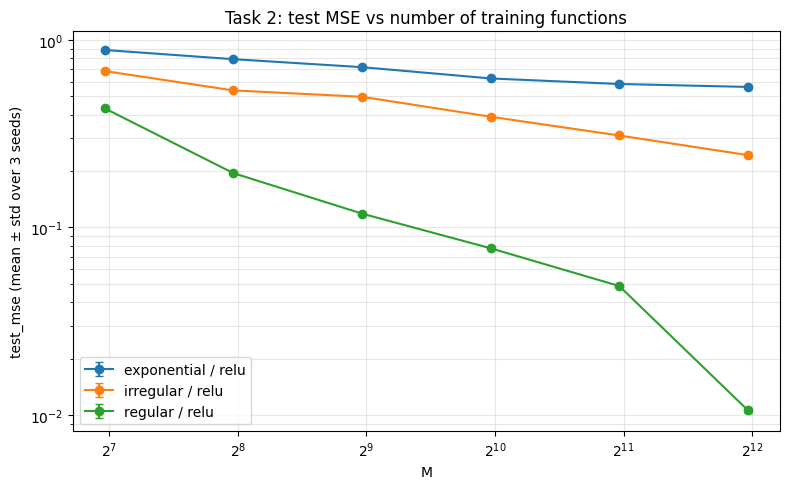

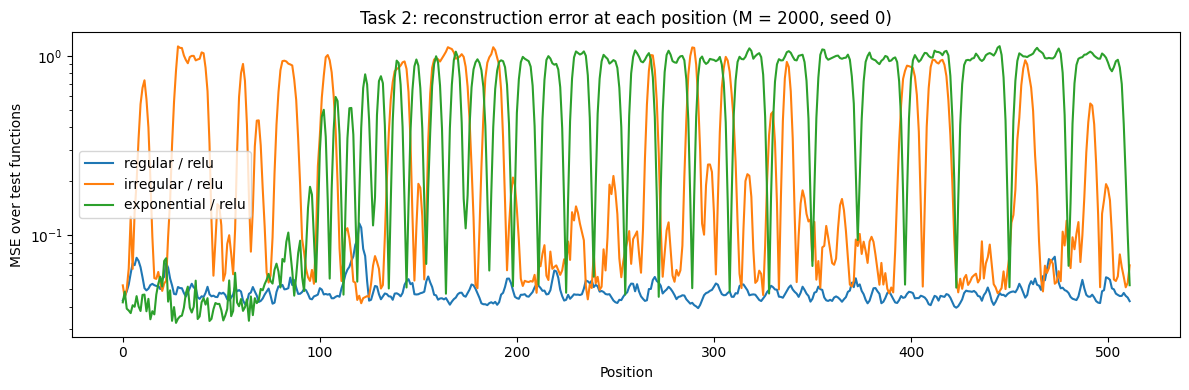

In [13]:
plot_vs_size(task2_size_df, 'M', 'test_mse', ['X', 'activation'], 'Task 2: test MSE vs number of training functions')

# 每個位置的平均誤差 看誤差集中在哪裡
fig, ax = plt.subplots(figsize=(12, 4))
for (kind, activation), errors in task2_position_errors.items():
    ax.plot(errors, label=f'{kind} / {activation}')
ax.set_yscale('log')
ax.set_xlabel('Position')
ax.set_ylabel('MSE over test functions')
ax.set_title('Task 2: reconstruction error at each position (M = 2000, seed 0)')
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- **Regular sampling benefits steadily from more data.** The test MSE falls from 0.43 at M = 125 to 0.011 at M = 4,000. A 32-fold increase in data reduces the error about 40-fold, roughly in proportion to 1/M, and the curve has not flattened, so more data would help further.
- **Irregular and exponential sampling improve much more slowly.** Irregular sampling goes from 0.68 to 0.24, and exponential sampling from 0.89 to 0.56, over the same range of M. The ranking regular < irregular < exponential holds at every M and for every seed, which supports the hypothesis.
- **The error sits in the gaps.** In the per-position plot, regular sampling has a uniformly low error (about 0.05). Exponential sampling has a low error near its dense samples at the start of the domain, but beyond position 100 the error oscillates between low values at the samples and about 1 inside the gaps, which means the network has no information there and falls back to the mean. Irregular sampling shows the same pattern at its own large gaps.
- **Comparison with the classical method.** With irregular sampling the DNN (0.24) is far worse than classical least squares (4.8e-4). With exponential sampling the classical method breaks down (2e7) while the DNN stays bounded at 0.56. The DNN is therefore more stable when the problem is badly conditioned, but it does not actually recover the missing parts of the function.

---
# Conclusions

**Task 1.** A DNN can memorise one band-limited function and interpolate it well, but only with the right architecture: the deeper sin network (6x128) reproduces the function to within about 5% of its variance, whereas a single wide layer and deep sigmoid networks learn little more than the mean. Depth helps more than width under a fixed neuron budget. The main difficulty is fitting the high frequencies at all (spectral bias), not the shape of the interpolation between points. More training points reduce the error, with the largest improvement around the Nyquist rate of about 98 regularly spaced points, although the transition is gradual because the 3x128 network underfits. Regular sampling is consistently better than irregular sampling, and periodic activations can overshoot badly in large gaps.

**Task 2.** A DNN can learn to reconstruct unseen band-limited functions from 100 samples: the ReLU baseline reaches about 5% relative error. Because reconstruction is a linear operation, a network without nonlinearities learns it essentially exactly, and all nonlinear networks are worse by many orders of magnitude, with smaller networks performing better than larger ones at M = 2,000. With regular sampling the error decreases roughly as 1/M. The choice of X matters more than any other factor we tested: irregular and especially exponential sampling leave gaps whose content cannot be inferred, and more data only slowly reduces this error. The DNN avoids the numerical breakdown of the classical least-squares method under exponential sampling, but it does not recover the information missing in the gaps.

**Limitations.** Many Task 1 runs stopped at the 5,000-epoch limit rather than at convergence, so their absolute errors are upper bounds. The dataset-size experiment in Task 2 uses only ReLU, the weakest activation in 2.2, so repeating it with the linear network would show whether a well-suited network also degrades under irregular sampling.